# LLM Usage Analysis
---

This notebook investigates LLM usage and cost data from the dataset provided and answers the 3 questions:
1. What is the overall LLM usage trend over time?
2. Which service is the biggest cost driver, and why?
3. Assumptions, exclusions, and transformations applied.

## 0  Setup & Imports

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [44]:
# Set visual style and colour scheme
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

# Colour scheme mapping for each of the four services
SERVICE_COLOURS = {
    'doc-analysis':       '#E07B39',  # orange
    'rag-api':            '#4C78A8',  # blue
    'chat-router':        '#54A24B',  # green
    'ticket-summarizer':  '#9E765F',  # brown
}

## 1  Load the Raw Data

Read the data directly from the `Raw Data` sheet of the workbook.  
`dtype={'date': str}` prevents pandas auto-parsing the date column so we can  
normalise the two different date formats ourselves later.


In [45]:
PATH = './NUSSIF_2026_INFRA_ASSESSMENT.xlsx'

df_raw = pd.read_excel(PATH, sheet_name='Raw Data', dtype={'date': str})

print(f"Loaded {len(df_raw):,} rows × {df_raw.shape[1]} columns")
df_raw.head(8)

Loaded 298 rows × 7 columns


,date,team,service,model,requests,total_tokens,cost_usd
0,2026-04-01,Platform,chat-router,gpt-4.1-mini,1360,506084.0,6.07
1,2026-04-01,Research,doc-analysis,gpt-4.1,126,245474.0,11.05
2,2026-04-01,Platform,rag-api,gpt-4.1-mini,911,588772.0,8.24
3,2026-04-01,Support,ticket-summarizer,gpt-4.1-mini,375,116438.0,1.28
4,2026-04-02,Platform,chat-router,gpt-4.1-mini,1065,456882.0,5.48
5,2026-04-02,Research,doc-analysis,gpt-4.1,208,447673.0,20.15
6,2026-04-02,Platform,rag-api,gpt-4.1-mini,949,616359.0,8.63
7,2026-04-02,Support,ticket-summarizer,gpt-4.1-mini,498,167464.0,1.84


## 2  Checking the Dataset provided

First, inspect the data for any issues.


In [46]:
# Out of 298 rows, total_tokens and cost_usd each have 1 null - to be handled during data cleaning. 
print("=== Schema ===")
df_raw.info()
print("=== Null counts ===")
print(df_raw.isnull().sum())

=== Schema ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298 entries, 0 to 297
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          298 non-null    object 
 1   team          298 non-null    object 
 2   service       298 non-null    object 
 3   model         298 non-null    object 
 4   requests      298 non-null    int64  
 5   total_tokens  297 non-null    float64
 6   cost_usd      297 non-null    float64
dtypes: float64(2), int64(1), object(4)
memory usage: 16.4+ KB
=== Null counts ===
date            0
team            0
service         0
model           0
requests        0
total_tokens    1
cost_usd        1
dtype: int64


In [47]:
# Summary of the quantitative variables to give a quick overview for any possible issues. 
# Two things that stand out: 
# Firstly, as mentioned above, the count for total_tokens and cost_usd is 297 even though there are 298 rows, confirming the nulls.
# In addition, the smallest value in the "requests" column is negative, which is impossible, indicating that there is likely an error in that data. 
# Other than that, the min and max values for total_tokens are whole numbers, which are to be expected. 
df_raw[['requests','total_tokens','cost_usd']].describe().round(2)

,requests,total_tokens,cost_usd
count,298.00,297.00,297.00
mean,751.44,434623.40,9.23
std,536.96,218087.71,9.81
min,-25.00,79595.00,0.88
25%,260.25,229029.00,2.73
50%,606.50,446211.00,7.38
75%,1137.75,576937.00,11.51
max,2408.00,1029364.00,134.26


In [48]:
# Check categorical variables.
# "team", "service" and "model" are all categorical variables. 

# We can identify some issues. 
# in "team" column, "platform" should be "Platform" - a casing inconsistency. 
# in the "service" column, "Chat Router" refers to the same service as "chat-router".

print("=== Unique 'team' values ===")
print(df_raw['team'].value_counts())
print()
print("=== Unique 'service' values ===")
print(df_raw['service'].value_counts())
print()
print("=== Unique 'model' values ===")
print(df_raw['model'].value_counts())


=== Unique 'team' values ===
team
Platform    148
Support      75
Research     74
platform      1
Name: count, dtype: int64

=== Unique 'service' values ===
service
ticket-summarizer    75
chat-router          74
doc-analysis         74
rag-api              74
Chat Router           1
Name: count, dtype: int64

=== Unique 'model' values ===
model
gpt-4.1-mini    224
gpt-4.1          74
Name: count, dtype: int64


In [49]:
# Check for non-standard date formats. 
# All rows use YYYY-MM-DD convention, but one row uses DD/MM/YYYY.
# This needs to be parsed separately to avoid misidentifying it as September 5th.
non_iso = df_raw[~df_raw['date'].str.match(r'^\d{4}-\d{2}-\d{2}$', na=False)]
print(non_iso[['date','team','service']].to_string(index=True))

           date     team            service
154  09/05/2026  Support  ticket-summarizer


In [50]:
# Find if there are any duplicate rows, and print them to check.
# We can see that there is 1 set of duplicated rows, of date 2026-04-04.
dups = df_raw[df_raw.duplicated(keep=False)].sort_values('date')
print(f"Exact duplicate row-pairs: {df_raw.duplicated().sum()}")
dups

Exact duplicate row-pairs: 1


,date,team,service,model,requests,total_tokens,cost_usd
12,2026-04-04,Platform,chat-router,gpt-4.1-mini,1036,421004.0,5.05
13,2026-04-04,Platform,chat-router,gpt-4.1-mini,1036,421004.0,5.05


In [51]:
# From the above numerical summary, we can see that the minimum was a negative value, which was likely incorrectly recorded. 
# Find all the rows where "requests" is a negative value - there is only one. 
# Since the data was likely incorrectly recorded and there is no basis to infer the correct value, it is better to remove this row.
neg = df_raw[df_raw['requests'] < 0]
print(f"Number of rows with requests < 0: {len(neg)}")
neg

Number of rows with requests < 0: 1


,date,team,service,model,requests,total_tokens,cost_usd
117,2026-04-30,Research,doc-analysis,gpt-4.1,-25,376783.0,16.96


In [52]:
# Before flagging outliers, we need to decide whether to compute z-scores globally or per service. 
# To justify the choice, first compare cost distributions across services. 
print(df_raw.groupby('service')['cost_usd'].describe().round(2))

                   count   mean    std    min    25%    50%    75%     max
service                                                                   
Chat Router          1.0   6.87    NaN   6.87   6.87   6.87   6.87    6.87
chat-router         74.0   7.35   2.05   1.93   5.86   7.34   8.80   12.35
doc-analysis        74.0  20.04  14.15  10.55  15.82  18.28  22.04  134.26
rag-api             74.0   7.92   1.90   4.52   6.59   7.60   9.35   11.97
ticket-summarizer   74.0   1.65   0.44   0.88   1.31   1.67   1.89    2.73


In [53]:
# The table above confirms that cost distributions vary quite largely by service.
# doc-analysis has a mean of ~$20 while chat-router ticket-summariser averages ~$1.65.
# Thus, check outliers on cost_usd using a per-service z-score. 
# Group by service because cost distributions differ significantly across services. 
# Flag rows where cost is more than 3 standard deviations above the service mean, indicating a likely outlier value.
cost_z = (df_raw['cost_usd'] - df_raw.groupby('service')['cost_usd'].transform('mean')) \
         / df_raw.groupby('service')['cost_usd'].transform('std')
outliers = df_raw[cost_z.abs() > 3]
print(f"Statistical outliers in cost_usd (|z| > 3), grouped by service: {len(outliers)}")
outliers

Statistical outliers in cost_usd (|z| > 3), grouped by service: 1


,date,team,service,model,requests,total_tokens,cost_usd
219,2026-05-26,Research,doc-analysis,gpt-4.1,270,621596.0,134.26


## 3  Data Cleaning & Transformation
In this section, based on the issues that were identified in section 2, we will deal with the respective issues.

### Issues found and how to handle each

| # | Issue | Decision |
|---|-------|----------|
| 1 | **Mixed date formats** - one row uses `DD/MM/YYYY` (09/05/2026) | Parse with `dayfirst` logic via `pd.to_datetime(errors='coerce')` then back-fill from the DD/MM format |
| 2 | **Case inconsistency in `team`** - `"platform"` vs `"Platform"` | `.str.strip().str.title()` |
| 3 | **Case inconsistency in `service`** - `"Chat Router"` vs `"chat-router"` | `.str.strip().str.lower().str.replace(' ', '-')` |
| 4 | **Exact duplicate row** — 2026-04-04 Platform / chat-router appears twice with identical values | Drop the duplicate occurrence |
| 5 | **Negative `requests`** — Research/doc-analysis on 2026-04-30 has -25 requests | Exclude row (due to impossible value; not much context) |
| 6 | **Missing `cost_usd`** — ticket-summarizer on 2026-05-03 | Impute using the service's average cost-per-token ratio |
| 7 | **Missing `total_tokens`** — rag-api on 2026-05-14 | Impute using the service's average tokens-per-request ratio |
| 8 | **Cost spike** — doc-analysis on 2026-05-26 costs 134.26 vs a typical 15–25 | **Retain but flag.** Token count (621 k) is elevated but plausible; the spike could reflect a large batch job. We note it and exclude only from the outlier-sensitive calculations. |


In [54]:
df = df_raw.copy()

# Fix 1: 
# Parse dates assuming ISO 8601 (YYYY-MM-DD), which covers almost all rows.
# Anything that doesn't match this format becomes NaT.
df['date'] = pd.to_datetime(df['date'], dayfirst=False, errors='coerce')

# Confirm that the one DD/MM/YYYY row ('09/05/2026') failed to parse and is now NaT.
nat_mask = df['date'].isna()
print(f"Rows that failed ISO parsing (NaT):")
print(df_raw.loc[nat_mask, 'date'].values)  # shows the original string that caused it

Rows that failed ISO parsing (NaT):
['09/05/2026']


In [55]:
# Fix 1 continued:
# Step 2: Re-parse only the NaT row with dayfirst=True.
# This correctly recovers '09/05/2026' as 2026-05-09, not 2026-09-05.
df.loc[nat_mask, 'date'] = pd.to_datetime(
    df_raw.loc[nat_mask, 'date'], dayfirst=True, errors='coerce'
)
print(f"Remaining NaT after parse: {df['date'].isna().sum()}")

Remaining NaT after parse: 0


In [56]:
# Fixed 2 and 3, naming inconsistency
df['team']    = df['team'].str.strip().str.title()
df['service'] = df['service'].str.strip().str.lower().str.replace(' ', '-', regex=False)

# check that the case inconsistency issues have been resolved
print("Teams after normalisation:   ", sorted(df['team'].unique()))
print("Services after normalisation:", sorted(df['service'].unique()))

Teams after normalisation:    ['Platform', 'Research', 'Support']
Services after normalisation: ['chat-router', 'doc-analysis', 'rag-api', 'ticket-summarizer']


In [57]:
# Fix 4: Drop exact duplicates
df = df.drop_duplicates()

In [58]:
# Fix 5: Drop negative requests
df = df[df['requests'] >= 0].copy()

In [59]:
# Fix 6: impute missing cost_usd for ticket-summarizer.

# The missing cost_usd row has valid total_tokens and requests values. 
# There are 2 imputation options: 
# (a) use the mean daily csot for ticket-summarizer directly
# (b) Derive cost from the mean cost-per-token rate * the row's actual token count

# Option (b) is preferable because cost is billed by token consumption. 
# Each row's token count varies, so a flat mean cost would over- or under-estimate depending on 
# whether this row processed more or fewer tokens than average. 
# Using the rate would give a closer estimate to the actual cost_usd.

# First, check that cost-per-token is stable across ticket-summarizer rows.
# If the ratio were highly variable, this imputation method would not be reliable.
ts_clean = df[(df['service'] == 'ticket-summarizer') & df['cost_usd'].notna()].copy()
ts_clean['cost_per_token'] = ts_clean['cost_usd'] / ts_clean['total_tokens']
print(f"ticket-summarizer cost-per-token — mean: {ts_clean['cost_per_token'].mean():.8f}, "
      f"std: {ts_clean['cost_per_token'].std():.8f}, "
      f"cv: {ts_clean['cost_per_token'].std() / ts_clean['cost_per_token'].mean():.3f}")
# The CV (coefficient of variation) value of 0.002 is small, and so the rate is consistent enough to impute from.

ticket-summarizer cost-per-token — mean: 0.00001100, std: 0.00000002, cv: 0.002


In [60]:
# Fix 6 (continued)
# Impute the missing cost using: imputed_cost = total_tokens × mean_rate
ts_cost_per_token = ts_clean['cost_per_token'].mean()
nan_cost_idx = df[df['cost_usd'].isnull()].index
df.loc[nan_cost_idx, 'cost_usd'] = (df.loc[nan_cost_idx, 'total_tokens'] * ts_cost_per_token).round(4)
print(f"Imputed cost_usd = ${df.loc[nan_cost_idx, 'cost_usd'].values[0]:.4f} "
      f"(for {df.loc[nan_cost_idx, 'requests'].values[0]} requests, "
      f"{int(df.loc[nan_cost_idx, 'total_tokens'].values[0]):,} tokens)")

Imputed cost_usd = $1.0429 (for 301 requests, 94,778 tokens)


In [61]:
# Fix 7: impute missing total_tokens for rag-api 
# The row with missing total_tokens has valid requests and cost_usd values. 
# To impute, could impute from cost (cost/cost-per-token = tokens) or from requests (requests * avg tokens/request)
# Use requests because tokens-per-requests reflect the more typical prompt/response length for this service, 
# cost can vary with pricing charges, while prompt length is generally more consistent. 

# First, verify the tokens-per-request ratio is stable for rag-api. 
rag_clean = df[(df['service'] == 'rag-api') & df['total_tokens'].notna()].copy()
rag_clean['tokens_per_req'] = rag_clean['total_tokens'] / rag_clean['requests']
print(f"rag-api tokens-per-request — mean: {rag_clean['tokens_per_req'].mean():,.1f}, "
      f"std: {rag_clean['tokens_per_req'].std():,.1f}, "
      f"cv: {rag_clean['tokens_per_req'].std() / rag_clean['tokens_per_req'].mean():.3f}")

rag-api tokens-per-request — mean: 614.3, std: 44.7, cv: 0.073


In [62]:
# Fix 7 continued
# The CV value of 0.073 is acceptably low
rag_tokens_per_req = (rag_clean['total_tokens'] / rag_clean['requests']).mean()
nan_tok_idx = df[df['total_tokens'].isnull()].index
imputed_tokens = df.loc[nan_tok_idx, 'requests'] * rag_tokens_per_req
df.loc[nan_tok_idx, 'total_tokens'] = imputed_tokens.round(0)
print(f"Imputed total_tokens = {int(df.loc[nan_tok_idx, 'total_tokens'].values[0]):,} "
      f"(for {df.loc[nan_tok_idx, 'requests'].values[0]} requests)")

Imputed total_tokens = 546,154 (for 889 requests)


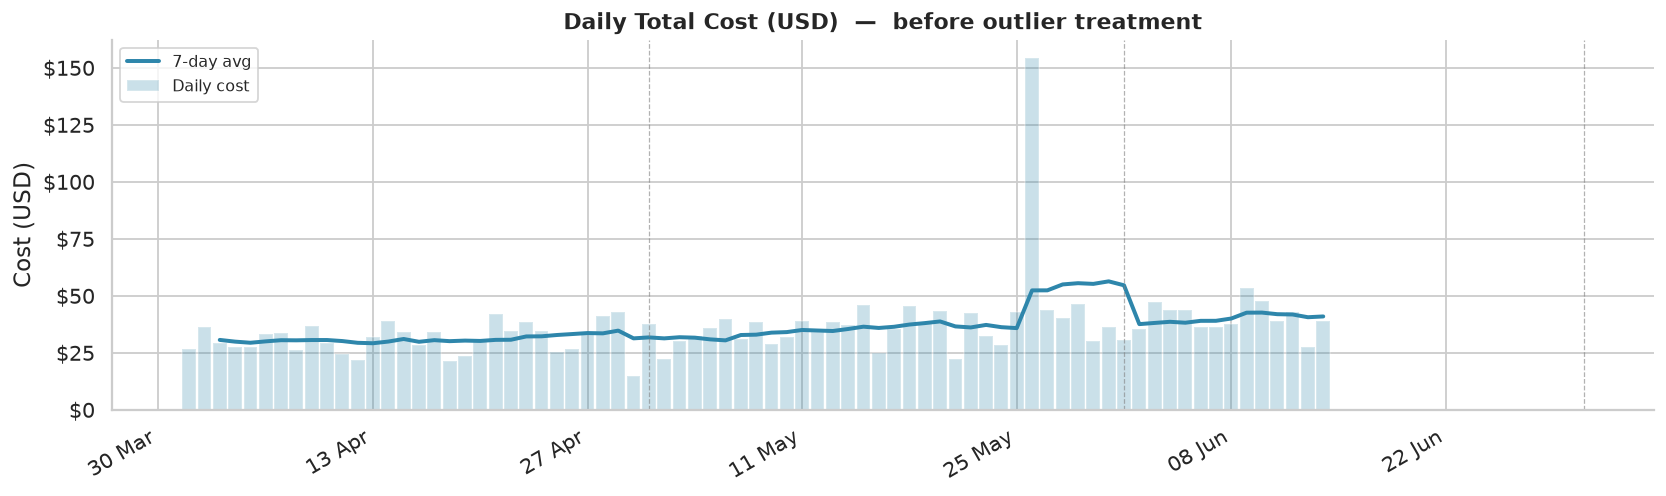

In [63]:
# Investigate issue 8, the sudden one day only cost spike
# Plot total daily cost and its 7-day rolling average to give a look at the trend
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(daily['date'], daily['total_cost'],
       color='#2E86AB', alpha=0.25, width=0.9, label='Daily cost')
ax.plot(daily['date'], daily['total_cost_7d'],
        color='#2E86AB', linewidth=2.2, label='7-day avg')

for m in pd.date_range('2026-05-01', '2026-07-01', freq='MS'):
    ax.axvline(m, color='grey', linestyle='--', linewidth=0.7, alpha=0.6)

ax.set_title('Daily Total Cost (USD)  —  before outlier treatment', fontsize=12, fontweight='bold')
ax.set_ylabel('Cost (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.xticks(rotation=30, ha='right')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# The spike on 2026-05-26 of doc-analysis, of $134.26, is clearly visibly an anomaly among the daily cost of other days and is 
# pulling the 7-day rolling average upward around that period, distorting the trend line. 

In [65]:
# To address this, rather than dropping the row (which would create a gap in the time series), 
# replace its cost with the median doc-analysis daily cost, computed from all non-outlier rows. 
# Use the median instead of the mean because the median is robust to outliers while the mean is not. 

spike_row = (df['date'] == '2026-05-26') & (df['service'] == 'doc-analysis')
print("Row with spike:")
print(df[spike_row][['date', 'service', 'requests', 'total_tokens', 'cost_usd']])
doc_median = df.loc[~spike_row & (df['service'] == 'doc-analysis'), 'cost_usd'].median()

print(f"doc-analysis median cost (excluding spike): ${doc_median:.2f}")

df.loc[spike_row, 'cost_usd'] = doc_median

Row with spike:
          date       service  requests  total_tokens  cost_usd
219 2026-05-26  doc-analysis       270      621596.0    134.26
doc-analysis median cost (excluding spike): $18.28


In [66]:
# Derived columns, and a brief justification for these columns. 
# Unit-cost ratios (cost_per_request, cost_per_1k_tokens) are needed for Q2's analysis on cost drivers, as they allow for comparison of services on
# a like-for-like basis. 

# week and month are pre-computed here for convenience as it is used in the groupby aggregations.
# week is used for the rolling trend charts; month is used for the period-over-period
# cost comparison by service.

df['cost_per_request'] = df['cost_usd'] / df['requests']
df['tokens_per_request'] = df['total_tokens'] / df['requests']
df['cost_per_1k_tokens'] = df['cost_usd'] / df['total_tokens'] * 1000
df['week']  = df['date'].dt.to_period('W').dt.start_time   # week start (Monday)
df['month'] = df['date'].dt.to_period('M').dt.to_timestamp()

print(f"Clean dataset: {len(df):,} rows")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
df.head(5)

Clean dataset: 296 rows
Date range: 2026-04-01 → 2026-06-14


,date,team,service,model,requests,total_tokens,cost_usd,cost_per_request,tokens_per_request,cost_per_1k_tokens,week,month
0,2026-04-01,Platform,chat-router,gpt-4.1-mini,1360,506084.0,6.07,0.004463,372.120588,0.011994,2026-03-30,2026-04-01
1,2026-04-01,Research,doc-analysis,gpt-4.1,126,245474.0,11.05,0.087698,1948.206349,0.045015,2026-03-30,2026-04-01
2,2026-04-01,Platform,rag-api,gpt-4.1-mini,911,588772.0,8.24,0.009045,646.291987,0.013995,2026-03-30,2026-04-01
3,2026-04-01,Support,ticket-summarizer,gpt-4.1-mini,375,116438.0,1.28,0.003413,310.501333,0.010993,2026-03-30,2026-04-01
4,2026-04-02,Platform,chat-router,gpt-4.1-mini,1065,456882.0,5.48,0.005146,428.997183,0.011994,2026-03-30,2026-04-01


## 4  Question 1 — Overall LLM Usage Trend Over Time

To assess the overall LLM usage trend over time, we examine three complementary signals: total daily cost,  
daily requests (volume), and daily token consumption (intensity of usage).  

The 7-day rolling average smooths weekend/weekday noise without obscuring the underlying directional trend.


In [67]:
# Aggregate to daily totals across all services
daily = df.groupby('date').agg(
    total_cost    = ('cost_usd',      'sum'),
    total_requests= ('requests',      'sum'),
    total_tokens  = ('total_tokens',  'sum'),
).reset_index().sort_values('date')

# 7-day rolling mean
for col in ['total_cost','total_requests','total_tokens']:
    daily[f'{col}_7d'] = daily[col].rolling(7, min_periods=3).mean()

daily.head(5)

,date,total_cost,total_requests,total_tokens,total_cost_7d,total_requests_7d,total_tokens_7d
0,2026-04-01,26.64,2772,1456768.0,NaN,NaN,NaN
1,2026-04-02,36.10,2720,1688378.0,NaN,NaN,NaN
2,2026-04-03,29.19,2843,1623631.0,30.643333,2778.333333,1.589592e+06
3,2026-04-04,27.64,1979,1241275.0,29.892500,2578.500000,1.502513e+06
4,2026-04-05,27.43,2238,1304105.0,29.400000,2510.400000,1.462831e+06


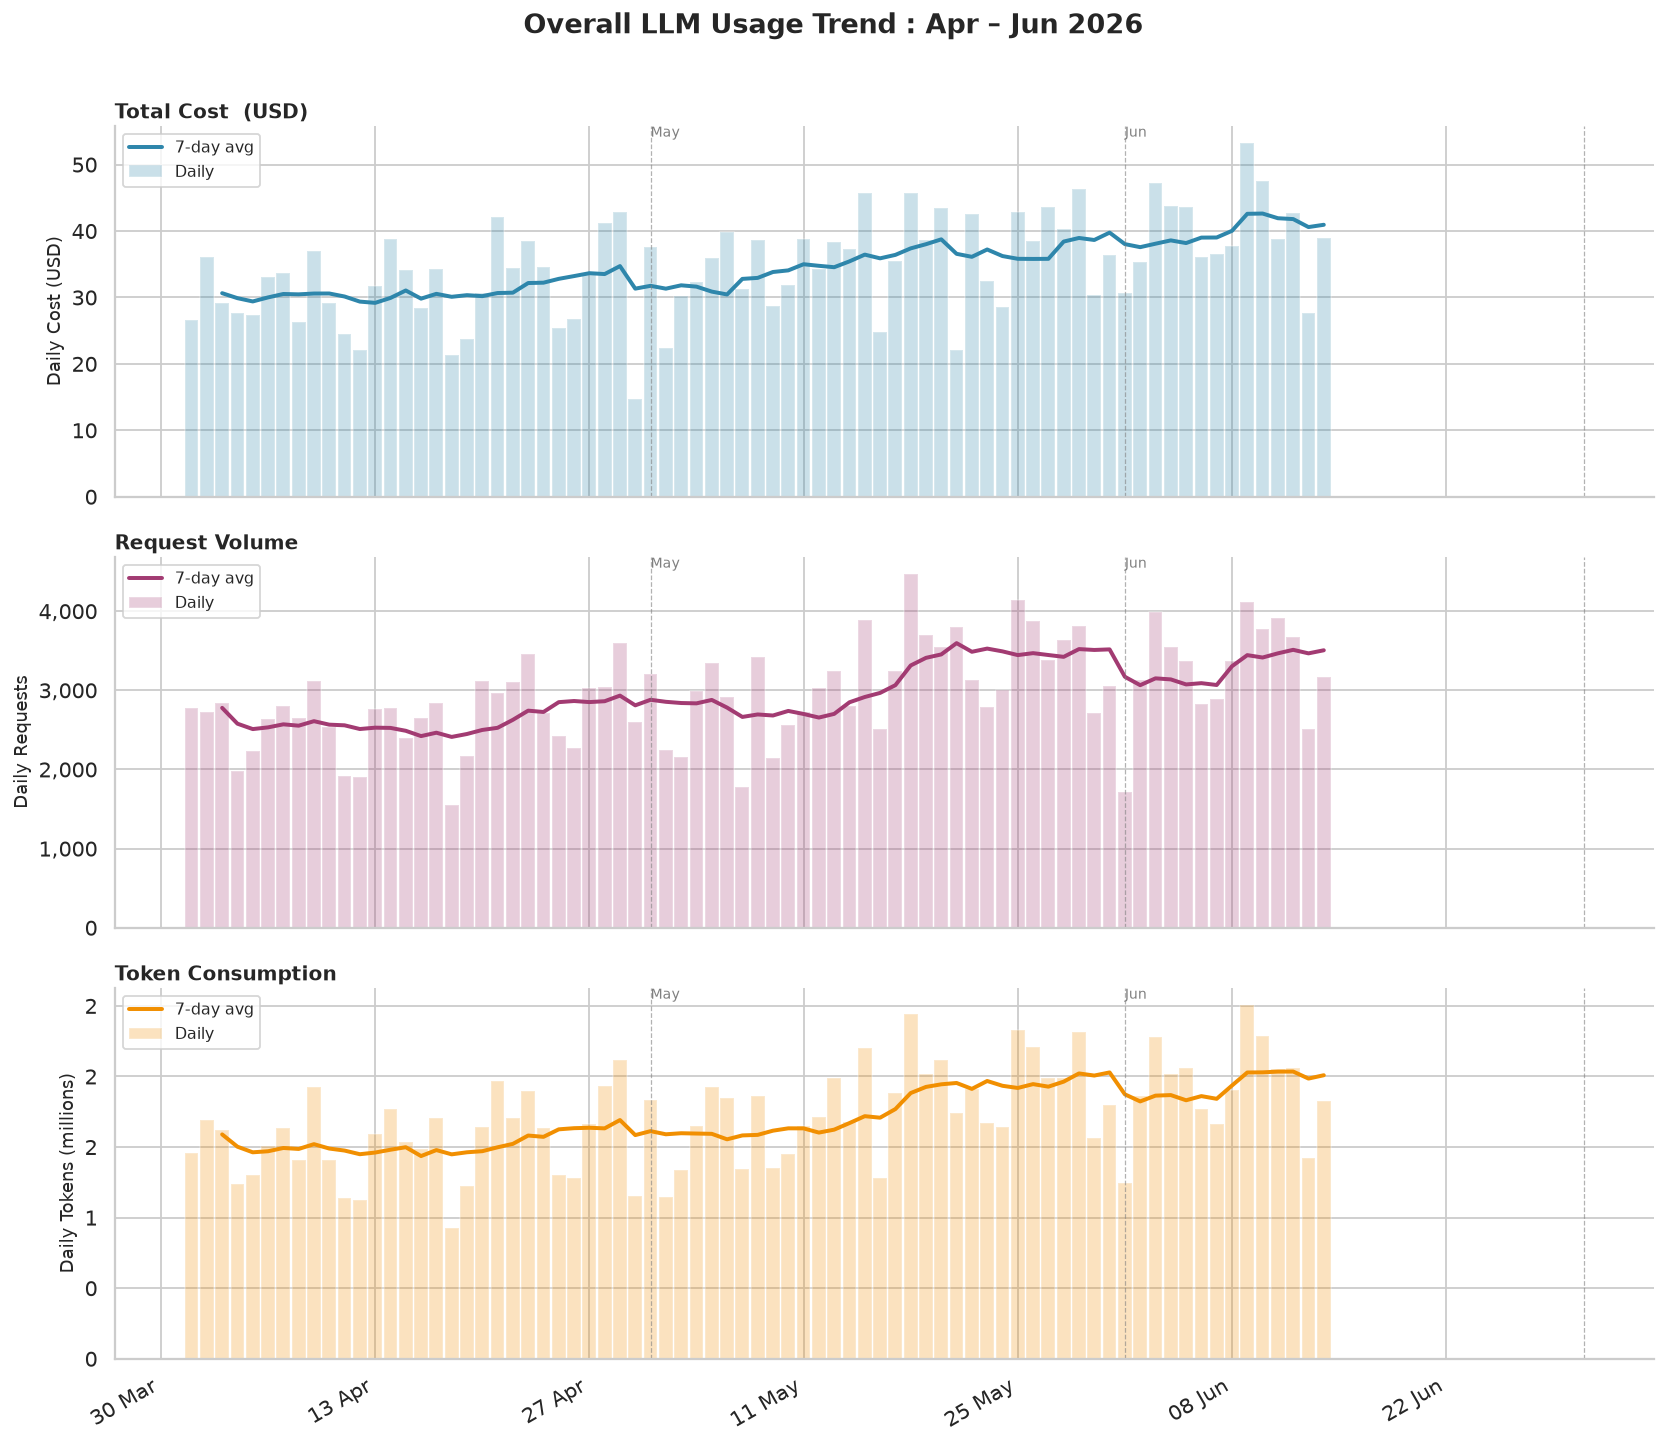

In [68]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
fig.suptitle('Overall LLM Usage Trend : Apr – Jun 2026', fontsize=15, fontweight='bold', y=1.01)

metrics = [
    ('total_cost',     'Daily Cost (USD)',        '#2E86AB', 'Total Cost  (USD)'),
    ('total_requests', 'Daily Requests',          '#A23B72', 'Request Volume'),
    ('total_tokens',   'Daily Tokens (millions)', '#F18F01', 'Token Consumption'),
]

for ax, (col, ylabel, colour, title) in zip(axes, metrics):
    scale = 1e6 if col == 'total_tokens' else 1

    # Raw daily bars
    ax.bar(daily['date'], daily[col] / scale,
           color=colour, alpha=0.25, width=0.9, zorder=1, label='Daily')

    # 7-day rolling line
    ax.plot(daily['date'], daily[f'{col}_7d'] / scale,
            color=colour, linewidth=2.2, zorder=2, label='7-day avg')

    # Month boundary lines
    for m in pd.date_range('2026-05-01', '2026-07-01', freq='MS'):
        ax.axvline(m, color='grey', linestyle='--', linewidth=0.7, alpha=0.6)
        if m <= daily['date'].max():
            ax.text(m, ax.get_ylim()[1] * 0.97,
                    m.strftime('%b'), fontsize=8, color='grey', ha='left')

    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='semibold', loc='left', pad=4)
    ax.legend(fontsize=9, loc='upper left')
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x:,.0f}' if col == 'total_cost' else f'{x:,.0f}')
    )

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# When looking at the trend in Total Cost, Request Volume and Token Consuimption over time, we can see that 
# there is a general increasing trend for each. 

# The increase in total cost is accompanied by increases in both request volume and token consumption. Because all three metrics 
# move in the same direction, the higher spending likely reflect greater LLM usage rather than just isolated prie changes or anomalous billing events.
# Although the overall trend is upward, daily usage fluctuates quite considerably. Across individual days, there are spikes and dips. 
# The 7-day rolling average smooths these fluctuations and reveals a long-term increase. This suggests that usage is affected by 
# day-to-day operational workloads, in addition to underlying growth trend.

# The growth is also not perfectly linear. After a relatively gradual increase through April, request volume and token consumption
# rise more noticeably during the second half of May before stabilising at a higher baseline in June. 

In [69]:
# Quantify the trend by fitting OLS slope on daily cost
from scipy.stats import linregress

x = (daily['date'] - daily['date'].min()).dt.days.values
y = daily['total_cost'].values
slope, intercept, r, p, se = linregress(x, y)

print(f"Linear regression on daily total cost:")
print(f"  Slope       : +${slope:.3f} / day  ({slope*7:.2f} / week, {slope*30:.2f} / month)")
print(f"  R-squared   : {r**2:.3f}")
print(f"  p-value     : {p:.4f}")
print()

# Compare first vs last week
first_week = daily.head(7)['total_cost'].mean()
last_week  = daily.tail(7)['total_cost'].mean()
print(f"  Avg daily cost — first 7 days : ${first_week:.2f}")
print(f"  Avg daily cost — last 7 days  : ${last_week:.2f}")
print(f"  Percentage increase           : +{(last_week/first_week - 1)*100:.1f}%")

# Linear regression on daily total cost reveals an upward trend that is statistically significant. 
# The slope of +0.225/day is statistically significant, with a p-value of less than 0.001, indicating that there is a linear relationship. 
# The average daily cost also rose 34% from $30.52 in the first week to $40.94 in the final week of the observed period. 

# However, an R-squared value of 0.239 indicates that only ~0.23 of the day-to-day cost variance is explained by time alone. 
# This suggests that the growth irregular rather than study, suggesting that usage is also driven by episodic factors 
# (eg batch jobs, specific team activity). 

Linear regression on daily total cost:
  Slope       : +$0.166 / day  (1.16 / week, 4.98 / month)
  R-squared   : 0.239
  p-value     : 0.0000

  Avg daily cost — first 7 days : $30.52
  Avg daily cost — last 7 days  : $40.94
  Percentage increase           : +34.1%


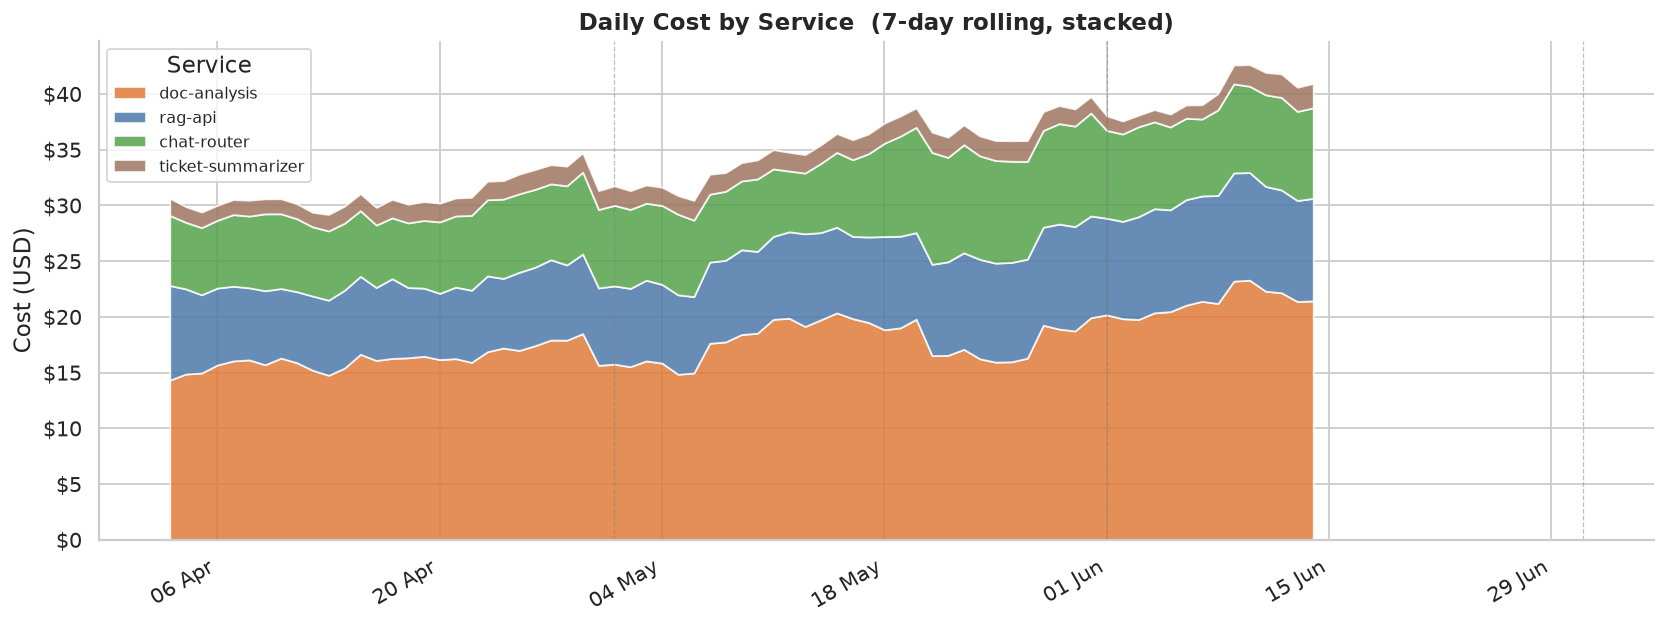

In [70]:
# Other than visualising the total cost across all services, 
# Here is also a chart to show how the total cost varies over time by service. 
# The stacked area shows the composition over time. 
# The relative composition of each service to cost is relatively stable over time
# with doc-analysis incurring the most daily cost, and ticket-summarizer the least.

daily_svc = df.groupby(['date','service'])['cost_usd'].sum().unstack(fill_value=0)
# Re-order by total cost descending so the biggest driver is at the bottom
order = daily_svc.sum().sort_values(ascending=False).index.tolist()
daily_svc = daily_svc[order]

# 7-day rolling per service
daily_svc_7d = daily_svc.rolling(7, min_periods=3).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(
    daily_svc_7d.index,
    [daily_svc_7d[s] for s in order],
    labels=order,
    colors=[SERVICE_COLOURS[s] for s in order],
    alpha=0.85,
)
for m in pd.date_range('2026-05-01', '2026-07-01', freq='MS'):
    ax.axvline(m, color='grey', linestyle='--', linewidth=0.7, alpha=0.5)

ax.set_title('Daily Cost by Service  (7-day rolling, stacked)', fontsize=13, fontweight='bold')
ax.set_ylabel('Cost (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.xticks(rotation=30, ha='right')
ax.legend(loc='upper left', fontsize=9, title='Service')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## 5  Question 2 - Which Service is the Biggest Cost Driver?

Decompose cost by: (a) total absolute spend, (b) request volume, (c) token volume,  
and (d) unit cost (cost per 1000 tokens).  


In [71]:
# Service-level summary
svc = df.groupby('service').agg(
    total_cost      = ('cost_usd',           'sum'),
    total_requests  = ('requests',           'sum'),
    total_tokens    = ('total_tokens',       'sum'),
    days_active     = ('date',               'nunique'),
    avg_cost_per_req= ('cost_per_request',   'mean'),
    median_cost_day = ('cost_usd',           lambda x: x.groupby(df.loc[x.index,'date']).sum().median()),
).reset_index().sort_values('total_cost', ascending=False)

svc['cost_share_pct']    = svc['total_cost']    / svc['total_cost'].sum()    * 100
svc['request_share_pct'] = svc['total_requests']/ svc['total_requests'].sum()* 100
svc['token_share_pct']   = svc['total_tokens']  / svc['total_tokens'].sum()  * 100
svc['cost_per_1k_tokens']= svc['total_cost']    / svc['total_tokens']        * 1000

print(svc[['service','total_cost','cost_share_pct','request_share_pct',
           'token_share_pct','cost_per_1k_tokens']].to_string(index=False))

          service  total_cost  cost_share_pct  request_share_pct  token_share_pct  cost_per_1k_tokens
     doc-analysis   1349.8200       51.807500           6.386625        23.450405            0.044679
          rag-api    586.3000       22.502806          30.638483        32.529146            0.013990
      chat-router    545.8300       20.949525          48.475455        35.307418            0.012000
ticket-summarizer    123.5029        4.740170          14.499437         8.713032            0.011002


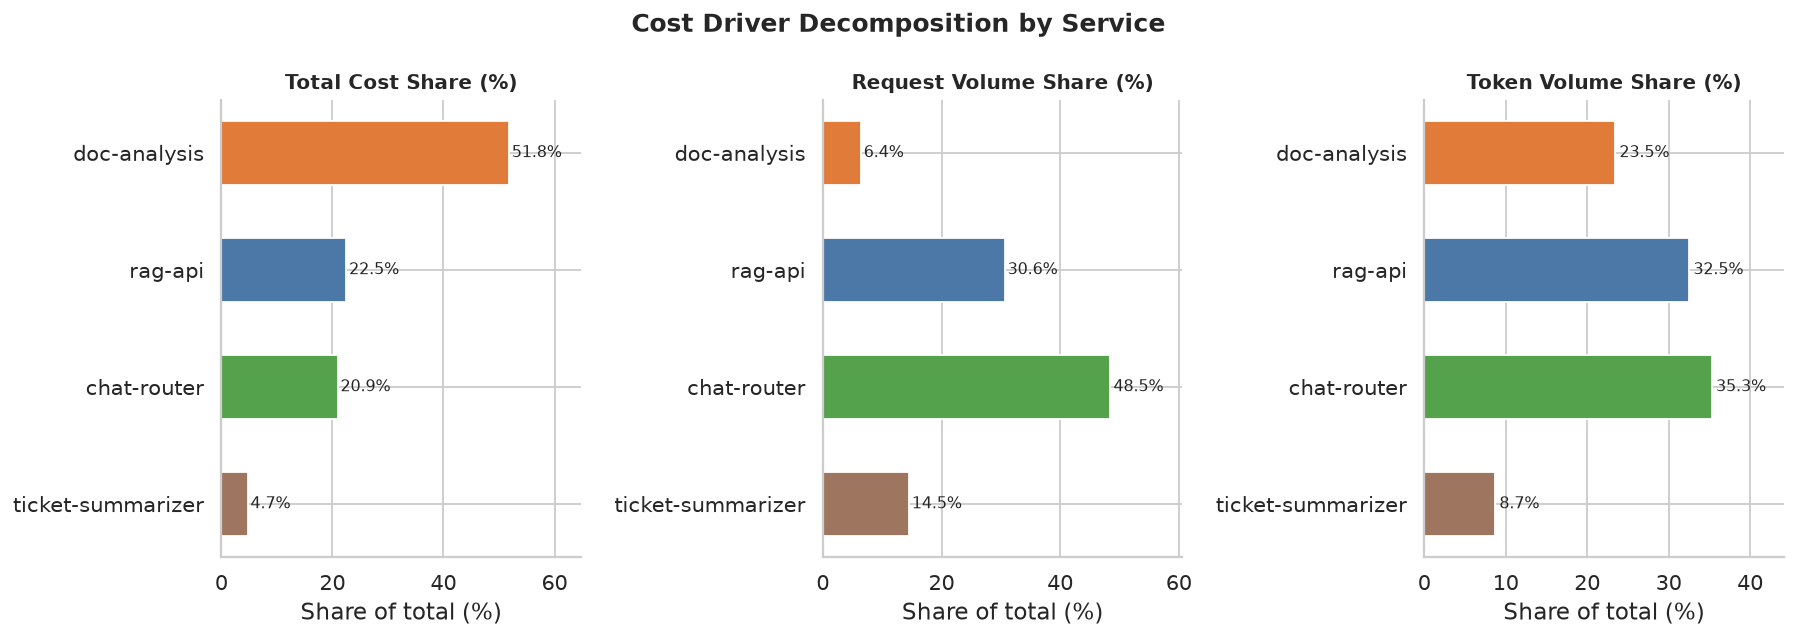

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Cost Driver Decomposition by Service', fontsize=14, fontweight='bold')

share_cols = [
    ('cost_share_pct',    'Total Cost Share (%)',    'Cost'),
    ('request_share_pct', 'Request Volume Share (%)', 'Requests'),
    ('token_share_pct',   'Token Volume Share (%)',   'Tokens'),
]

for ax, (col, title, label) in zip(axes, share_cols):
    bars = ax.barh(
        svc['service'],
        svc[col],
        color=[SERVICE_COLOURS[s] for s in svc['service']],
        edgecolor='white',
        height=0.55,
    )
    for bar, val in zip(bars, svc[col]):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    ax.set_xlim(0, svc[col].max() * 1.25)
    ax.set_title(title, fontsize=11, fontweight='semibold')
    ax.set_xlabel('Share of total (%)')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


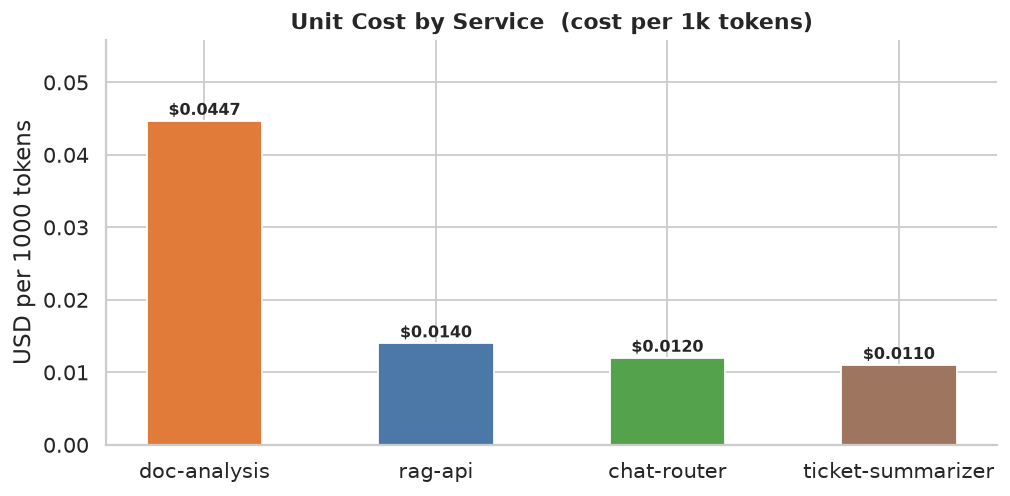

In [73]:
# Unit cost comparison (cost per 1000 tokens) 
fig, ax = plt.subplots(figsize=(8, 4))

colours = [SERVICE_COLOURS[s] for s in svc['service']]
bars = ax.bar(svc['service'], svc['cost_per_1k_tokens'], color=colours, width=0.5, edgecolor='white')

for bar, val in zip(bars, svc['cost_per_1k_tokens']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0003,
            f'${val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('USD per 1000 tokens')
ax.set_title('Unit Cost by Service  (cost per 1k tokens)', fontsize=12, fontweight='bold')
ax.set_ylim(0, svc['cost_per_1k_tokens'].max() * 1.25)
plt.tight_layout()
plt.show()


In [74]:
model_cost_table = df.groupby(['service', 'model']).agg(
    total_cost_usd  = ('cost_usd',      'sum'),
    total_tokens    = ('total_tokens',  'sum'),
    total_requests  = ('requests',      'sum'),
).reset_index()

model_cost_table['cost_per_1k_tokens'] = (
    model_cost_table['total_cost_usd'] / model_cost_table['total_tokens'] * 1000
)
model_cost_table['cost_share_pct'] = (
    model_cost_table['total_cost_usd'] / model_cost_table['total_cost_usd'].sum() * 100
)
model_cost_table['token_share_pct'] = (
    model_cost_table['total_tokens'] / model_cost_table['total_tokens'].sum() * 100
)

model_cost_table['request_share_pct'] = (
    model_cost_table['total_requests'] / model_cost_table['total_requests'].sum() * 100
)

model_cost_table = model_cost_table.sort_values('total_cost_usd', ascending=False)
model_cost_table[['service', 'model', 'total_cost_usd', 'cost_share_pct',
                   'request_share_pct', 'token_share_pct', 'cost_per_1k_tokens']].round(3)

,service,model,total_cost_usd,cost_share_pct,request_share_pct,token_share_pct,cost_per_1k_tokens
1,doc-analysis,gpt-4.1,1349.820,51.807,6.387,23.450,0.045
2,rag-api,gpt-4.1-mini,586.300,22.503,30.638,32.529,0.014
0,chat-router,gpt-4.1-mini,545.830,20.950,48.475,35.307,0.012
3,ticket-summarizer,gpt-4.1-mini,123.503,4.740,14.499,8.713,0.011


### Cost driver findings

**`doc-analysis` is the dominant cost driver**, accounting for 51.8% of total LLM spending
despite handling only 6.4% of all requests, and 23.5% of total tokens.

From the table above, we can see that `doc-analysis` is the primary cost driver, but this is not because it processes the largest number of requests, 
as it only accounts for 6.4% of total requests, nor is it solely due to token volume, as it consumes 23.5% of all tokens, less than both 
chat-router (35.3%) and rag-api (32.5%). 

The dominant factor is much higher unit cost. At approximately 0.0447 USD/1k tokens, doc-analysis is more than 3 times as expensive per token as the other services. 

Looking at the model used by each service, a likely reason is that `doc-analysis` processes documents using gpt-4.1, which carries  
a ~4× higher token price than the gpt-4.1-mini used by all other services. Although it consumes only 22% of total tokens, that premium pricing makes it account for more than half of the bill.

Looking at the other 3 services which all use the gpt-4.1-mini model, the cost per 1k tokens is relatively stable between 0.011-0.014 USD/1k tokens. 
This indicates that the model, rather than the service, has a greater effect on determining the eventual cost. 